In [2]:
!nvidia-smi

Tue Feb 17 12:16:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# for pytorch
import torch
print("Is GPU available?", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

Is GPU available? True
GPU Name: Tesla T4


In [4]:
# tensorflow
import tensorflow as tf
print("Found GPU at:", tf.test.gpu_device_name())

Found GPU at: /device:GPU:0


In [5]:
# The "Stress Test" (Check if GPU actually works)
import tensorflow as tf
import time

# Verify GPU
with tf.device('/device:GPU:0'):
    a = tf.random.normal([10000, 10000])
    b = tf.random.normal([10000, 10000])

    start = time.time()
    c = tf.matmul(a, b)
    print(f"Matrix multiplication took: {time.time() - start:.4f} seconds")

Matrix multiplication took: 0.1105 seconds


# ==========================================
# DEEP LEARNING FOR FINANCE - PROJECT
# STEP 1: Data, Leakage, and Initial Models
# ==========================================

In [6]:
! pip install pyts

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.optimizers import Adam

# Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Gramian Angular Field for CNN
from pyts.image import GramianAngularField

# ---------------------------------------------------------
# Step 1a: Gather Information & Data (Max 2000 obs)
# ---------------------------------------------------------

/tmp/ipython-input-2831299988.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01", end="2024-01-01", progress=False)


Data Loaded: BTC-USD, Shape: (2000, 1)


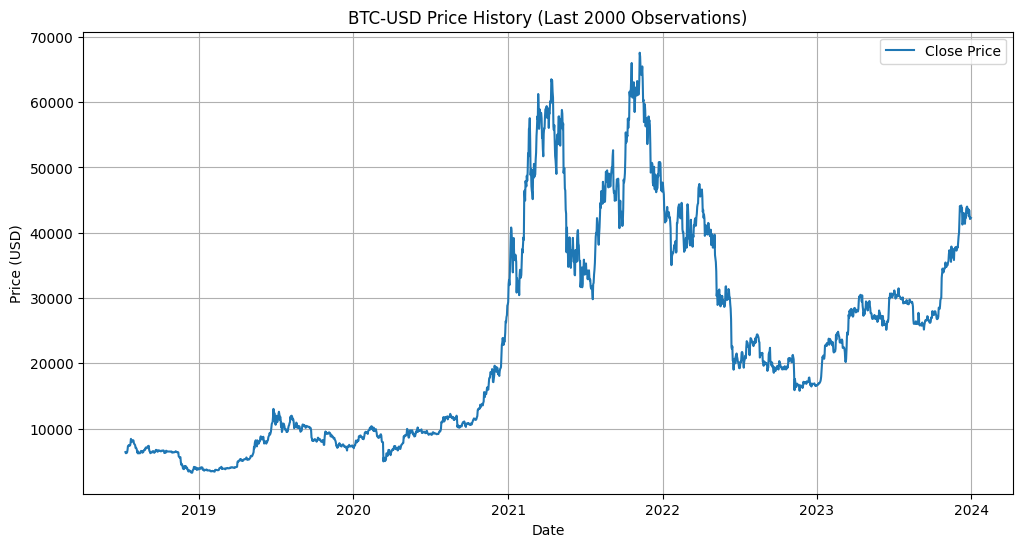

In [8]:
ticker = "BTC-USD"
# Fetch enough data to get 2000 points
data = yf.download(ticker, start="2018-01-01", end="2024-01-01", progress=False)

# Clean and limit to 2000 observations as per constraints [cite: 14]
df = data[['Close']].copy()
df = df.dropna()
if len(df) > 2000:
    df = df.iloc[-2000:]

print(f"Data Loaded: {ticker}, Shape: {df.shape}")

# Visualization of the Time Series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title(f"{ticker} Price History (Last 2000 Observations)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# Step 1b: Build Predictive Model & Induce Leakage
# ---------------------------------------------------------

In [9]:
# We will treat this as a Classification problem: Predict if Return > 0 (Up) or <= 0 (Down)
# LEAKAGE MECHANISM: Scaling the ENTIRE dataset before splitting.
# This leaks future information (mean/std of test set) into training.

# Calculate Returns
df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

# Create Labels (1 if next day return is positive, else 0)
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)
df.dropna(inplace=True) # Drop last row with NaN target

# Feature Engineering
window_size = 20  # Use past 20 days to predict next day

# Prepare input sequences (X) and labels (y)
X_raw = []
y = []

# Using 'Return' as the feature
feature_data = df['Return'].values

for i in range(len(feature_data) - window_size):
    X_raw.append(feature_data[i : i + window_size])
    y.append(df['Target'].iloc[i + window_size])

X_raw = np.array(X_raw)
y = np.array(y)

# --- INDUCING LEAKAGE  ---
# Normalize the entire X dataset BEFORE splitting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
# X_scaled now contains information about the distribution of the Test set.

# Reshaping for different models
# MLP: (Samples, Features) -> Already (N, 20)
X_mlp = X_scaled

# LSTM: (Samples, Time Steps, Features) -> (N, 20, 1)
X_lstm = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# CNN-GAF: Transform Time Series to Images
print("Generating Gramian Angular Fields (this may take a moment)...")
gaf = GramianAngularField(image_size=20, method='summation')
X_gaf = gaf.fit_transform(X_scaled)
# Reshape for CNN: (Samples, Height, Width, Channels) -> (N, 20, 20, 1)
X_cnn = X_gaf.reshape((X_gaf.shape[0], 20, 20, 1))

# Split Data (Single Split for Step 1)
split_idx = int(len(X_scaled) * 0.8)

X_mlp_train, X_mlp_test = X_mlp[:split_idx], X_mlp[split_idx:]
X_lstm_train, X_lstm_test = X_lstm[:split_idx], X_lstm[split_idx:]
X_cnn_train, X_cnn_test = X_cnn[:split_idx], X_cnn[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training Samples: {len(y_train)}, Test Samples: {len(y_test)}")

Generating Gramian Angular Fields (this may take a moment)...
Training Samples: 1583, Test Samples: 396


# ---------------------------------------------------------
# Step 1c: Three DL Models (MLP, LSTM, GAF-CNN)
# ---------------------------------------------------------

In [10]:
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train Models
epochs = 20
batch_size = 32

print("\n>>> Training MLP...")
mlp_model = build_mlp(X_mlp_train.shape[1])
history_mlp = mlp_model.fit(X_mlp_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_mlp_test, y_test), verbose=0)

print(">>> Training LSTM...")
lstm_model = build_lstm((X_lstm_train.shape[1], 1))
history_lstm = lstm_model.fit(X_lstm_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_lstm_test, y_test), verbose=0)

print(">>> Training CNN (GAF)...")
cnn_model = build_cnn((20, 20, 1))
history_cnn = cnn_model.fit(X_cnn_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_cnn_test, y_test), verbose=0)


>>> Training MLP...
>>> Training LSTM...
>>> Training CNN (GAF)...


# ---------------------------------------------------------
# Step 1d: Backtest Results (Vectorized Backtest)
# ---------------------------------------------------------


Results (Accuracy):
MLP: 0.5278
LSTM: 0.4823
CNN: 0.5076


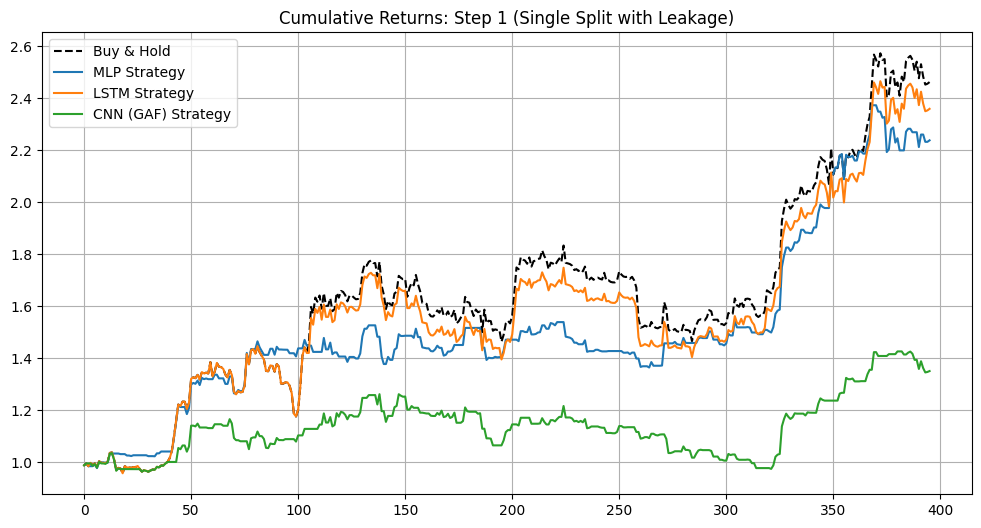

In [11]:
def evaluate_strategy(model, X_test, y_test, prices_test):
    # Predict probabilities
    probs = model.predict(X_test, verbose=0).flatten()
    # Signal: 1 (Buy) if Prob > 0.5 else 0 (Hold/Sell) - Simple strategy
    predictions = (probs > 0.5).astype(int)

    # Calculate Accuracy
    acc = accuracy_score(y_test, predictions)

    # Calculate Returns of the Strategy
    # We need the actual returns corresponding to the test set
    # Note: X_test corresponds to windows ending at t, predicting t+1.
    # We need returns at t+1.

    # Extract actual returns from the price data slice corresponding to y_test
    # (This is an approximation for the vector backtest; precise index alignment is critical in production)
    strategy_returns = prices_test * predictions
    cumulative_returns = (1 + strategy_returns).cumprod()
    buy_hold_returns = (1 + prices_test).cumprod()

    return acc, cumulative_returns, buy_hold_returns

# Extract test set returns for backtesting
# The test set starts at split_idx. y_test[0] corresponds to the return at split_idx + window_size
test_returns = df['Return'].values[split_idx + window_size:]

# Ensure lengths match (sometimes off by 1 due to slicing)
min_len = min(len(y_test), len(test_returns))
y_test = y_test[:min_len]
test_returns = test_returns[:min_len]
X_mlp_test = X_mlp_test[:min_len]
X_lstm_test = X_lstm_test[:min_len]
X_cnn_test = X_cnn_test[:min_len]

# Evaluate
acc_mlp, ret_mlp, bh = evaluate_strategy(mlp_model, X_mlp_test, y_test, test_returns)
acc_lstm, ret_lstm, _ = evaluate_strategy(lstm_model, X_lstm_test, y_test, test_returns)
acc_cnn, ret_cnn, _ = evaluate_strategy(cnn_model, X_cnn_test, y_test, test_returns)

print(f"\nResults (Accuracy):")
print(f"MLP: {acc_mlp:.4f}")
print(f"LSTM: {acc_lstm:.4f}")
print(f"CNN: {acc_cnn:.4f}")

# Plotting Backtest
plt.figure(figsize=(12, 6))
plt.plot(bh, label='Buy & Hold', color='black', linestyle='--')
plt.plot(ret_mlp, label='MLP Strategy')
plt.plot(ret_lstm, label='LSTM Strategy')
plt.plot(ret_cnn, label='CNN (GAF) Strategy')
plt.title("Cumulative Returns: Step 1 (Single Split with Leakage)")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# STEP 2: Walk-Forward Analysis (With Leakage)
# ==========================================

In [12]:
# Helper function for Non-Anchored Walk Forward
def walk_forward_validation(model_builder, X_data, y_data, train_size, test_size, model_type='mlp'):
    """
    Performs non-anchored walk-forward validation.
    """
    predictions = []
    actuals = []

    # Calculate number of folds
    # We start at train_size and move by test_size steps
    current_index = train_size
    n_samples = len(X_data)

    fold = 0
    while current_index + test_size <= n_samples:
        fold += 1

        # SLICING (Non-Anchored / Rolling Window)
        # Train window: [current - train_size : current]
        # Test window:  [current : current + test_size]
        start_train = current_index - train_size
        end_train = current_index
        end_test = end_train + test_size

        X_train_fold = X_data[start_train:end_train]
        y_train_fold = y_data[start_train:end_train]
        X_test_fold = X_data[end_train:end_test]
        y_test_fold = y_data[end_train:end_test]

        # Build and Train Model (Retraining for every fold)
        # We use a smaller epoch count for speed in WF loops, but enough to learn
        if model_type == 'mlp':
            model = model_builder(X_train_fold.shape[1])
            epochs_wf = 10
        elif model_type == 'lstm':
            model = model_builder((X_train_fold.shape[1], 1))
            epochs_wf = 10
        elif model_type == 'cnn':
            model = model_builder((20, 20, 1)) # Fixed GAF size
            epochs_wf = 10

        model.fit(X_train_fold, y_train_fold, epochs=epochs_wf, batch_size=32, verbose=0)

        # Predict
        probs = model.predict(X_test_fold, verbose=0).flatten()
        preds = (probs > 0.5).astype(int)

        predictions.extend(preds)
        actuals.extend(y_test_fold)

        # Move window
        current_index += test_size

        print(f"Fold {fold}: Train[{start_train}:{end_train}] Test[{end_train}:{end_test}] - Completed")

    return np.array(actuals), np.array(predictions)

# ---------------------------------------------------------
# Step 2a: Walk Forward (Train=500, Test=500)
# ---------------------------------------------------------

In [13]:
# We use the X_mlp, X_lstm, X_cnn variables from Step 1 (which are GLOBALLY SCALED -> Leakage)

# MLP WF 500/500
print("Running MLP WF (500/500)...")
y_true_2a_mlp, y_pred_2a_mlp = walk_forward_validation(build_mlp, X_mlp, y, 500, 500, 'mlp')

# LSTM WF 500/500
print("Running LSTM WF (500/500)...")
y_true_2a_lstm, y_pred_2a_lstm = walk_forward_validation(build_lstm, X_lstm, y, 500, 500, 'lstm')

# CNN WF 500/500
print("Running CNN WF (500/500)...")
y_true_2a_cnn, y_pred_2a_cnn = walk_forward_validation(build_cnn, X_cnn, y, 500, 500, 'cnn')

Running MLP WF (500/500)...
Fold 1: Train[0:500] Test[500:1000] - Completed
Fold 2: Train[500:1000] Test[1000:1500] - Completed
Running LSTM WF (500/500)...
Fold 1: Train[0:500] Test[500:1000] - Completed
Fold 2: Train[500:1000] Test[1000:1500] - Completed
Running CNN WF (500/500)...
Fold 1: Train[0:500] Test[500:1000] - Completed
Fold 2: Train[500:1000] Test[1000:1500] - Completed


# ---------------------------------------------------------
# Step 2b: Walk Forward (Train=500, Test=100)
# ---------------------------------------------------------

In [14]:
# MLP WF 500/100
print("Running MLP WF (500/100)...")
y_true_2b_mlp, y_pred_2b_mlp = walk_forward_validation(build_mlp, X_mlp, y, 500, 100, 'mlp')

# LSTM WF 500/100
print("Running LSTM WF (500/100)...")
y_true_2b_lstm, y_pred_2b_lstm = walk_forward_validation(build_lstm, X_lstm, y, 500, 100, 'lstm')

# CNN WF 500/100
print("Running CNN WF (500/100)...")
y_true_2b_cnn, y_pred_2b_cnn = walk_forward_validation(build_cnn, X_cnn, y, 500, 100, 'cnn')

Running MLP WF (500/100)...
Fold 1: Train[0:500] Test[500:600] - Completed


Fold 2: Train[100:600] Test[600:700] - Completed
Fold 3: Train[200:700] Test[700:800] - Completed
Fold 4: Train[300:800] Test[800:900] - Completed
Fold 5: Train[400:900] Test[900:1000] - Completed
Fold 6: Train[500:1000] Test[1000:1100] - Completed
Fold 7: Train[600:1100] Test[1100:1200] - Completed
Fold 8: Train[700:1200] Test[1200:1300] - Completed
Fold 9: Train[800:1300] Test[1300:1400] - Completed
Fold 10: Train[900:1400] Test[1400:1500] - Completed
Fold 11: Train[1000:1500] Test[1500:1600] - Completed
Fold 12: Train[1100:1600] Test[1600:1700] - Completed
Fold 13: Train[1200:1700] Test[1700:1800] - Completed
Fold 14: Train[1300:1800] Test[1800:1900] - Completed
Running LSTM WF (500/100)...
Fold 1: Train[0:500] Test[500:600] - Completed
Fold 2: Train[100:600] Test[600:700] - Completed
Fold 3: Train[200:700] Test[700:800] - Completed
Fold 4: Train[300:800] Test[800:900] - Completed
Fold 5: Train[400:900] Test[900:1000] - Completed
Fold 6: Train[500:1000] Test[1000:1100] - Completed
F

# ---------------------------------------------------------
# Results Comparison
# ---------------------------------------------------------


=== Step 2 Results: Accuracy Comparison ===
Step 2a (500/500) | MLP: 0.4940
Step 2a (500/500) | LSTM: 0.5070
Step 2a (500/500) | CNN: 0.5140
----------------------------------------
Step 2b (500/100) | MLP: 0.5286
Step 2b (500/100) | LSTM: 0.5143
Step 2b (500/100) | CNN: 0.5171


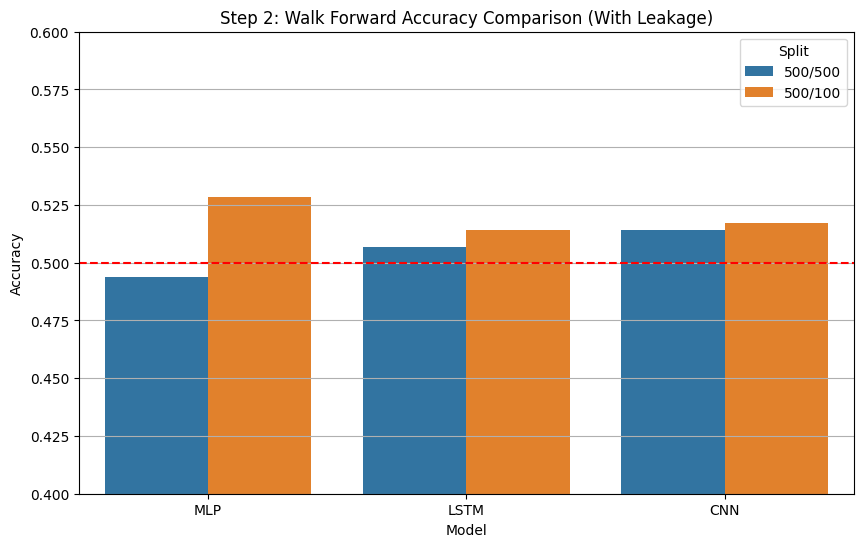

In [15]:
print("\n=== Step 2 Results: Accuracy Comparison ===")
print(f"Step 2a (500/500) | MLP: {accuracy_score(y_true_2a_mlp, y_pred_2a_mlp):.4f}")
print(f"Step 2a (500/500) | LSTM: {accuracy_score(y_true_2a_lstm, y_pred_2a_lstm):.4f}")
print(f"Step 2a (500/500) | CNN: {accuracy_score(y_true_2a_cnn, y_pred_2a_cnn):.4f}")
print("-" * 40)
print(f"Step 2b (500/100) | MLP: {accuracy_score(y_true_2b_mlp, y_pred_2b_mlp):.4f}")
print(f"Step 2b (500/100) | LSTM: {accuracy_score(y_true_2b_lstm, y_pred_2b_lstm):.4f}")
print(f"Step 2b (500/100) | CNN: {accuracy_score(y_true_2b_cnn, y_pred_2b_cnn):.4f}")

# Visualization of Accuracy Comparison
results_step2 = {
    'Model': ['MLP', 'LSTM', 'CNN', 'MLP', 'LSTM', 'CNN'],
    'Split': ['500/500', '500/500', '500/500', '500/100', '500/100', '500/100'],
    'Accuracy': [
        accuracy_score(y_true_2a_mlp, y_pred_2a_mlp),
        accuracy_score(y_true_2a_lstm, y_pred_2a_lstm),
        accuracy_score(y_true_2a_cnn, y_pred_2a_cnn),
        accuracy_score(y_true_2b_mlp, y_pred_2b_mlp),
        accuracy_score(y_true_2b_lstm, y_pred_2b_lstm),
        accuracy_score(y_true_2b_cnn, y_pred_2b_cnn)
    ]
}

df_res2 = pd.DataFrame(results_step2)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_res2, x='Model', y='Accuracy', hue='Split')
plt.title("Step 2: Walk Forward Accuracy Comparison (With Leakage)")
plt.ylim(0.4, 0.6) # Focus on the relevant range around 0.5
plt.axhline(0.5, color='red', linestyle='--')
plt.grid(True, axis='y')
plt.show()

# ==========================================
# STEP 3: Walk-Forward Analysis (NO LEAKAGE)
# ==========================================

In [16]:
# ============================================================
# STEP 3: Leakage-Free Walk-Forward (Optimized + Stable)
# Includes:
#   - Step 3a: (Optional) Quick sanity run (small sizes)
#   - Step 3b: WF No Leakage (500/500)
#   - Step 3c: WF No Leakage (500/100)
# ============================================================

import os
import gc
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from pyts.image import GramianAngularField

print("\n>>> STARTING STEP 3: Leakage-Free Walk-Forward (Optimized + Stable) <<<")

# ---------------------------
# (Recommended) GPU stability
# ---------------------------
# Enable memory growth so TF doesn't pre-allocate all VRAM.
# Put this BEFORE building/creating models.
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU detected: enabled memory growth.")
    except Exception as e:
        print("Could not set GPU memory growth:", e)
else:
    print("No GPU detected (running on CPU).")

# ------------------------------------------------------------
# NOTE:
# makes sure to run previous cells first
# ------------------------------------------------------------

def walk_forward_no_leakage_optimized(
    model_builder,
    X_raw_data,
    y_data,
    train_size,
    test_size,
    model_type="mlp",
    epochs=5,
    batch_size=64,
    stride=None,                # if None, uses stride=test_size (true walk-forward blocks)
    image_size=20,
    verbose_every=5
):
    """
    Leakage-free walk-forward:
      - scaler is fit ONLY on each train fold
      - test fold only transformed
      - models rebuilt each fold (with aggressive cleanup) for simplicity/stability
        (You can also warm-start, but rebuilding is clearer for coursework/reports)

    stride:
      - If stride == test_size -> non-overlapping test blocks (common WF)
      - If stride == 1         -> sliding window WF (more folds, heavier)
    """
    predictions = []
    actuals = []

    n_samples = len(X_raw_data)
    current_index = train_size
    fold = 0

    if stride is None:
        stride = test_size

    # Create GAF transformer ONCE (no fitting needed)
    gaf = None
    if model_type == "cnn":
        gaf = GramianAngularField(image_size=image_size, method="summation")

    while current_index + test_size <= n_samples:
        fold += 1

        # ----------------------------
        # Memory Cleanup (per fold)
        # ----------------------------
        tf.keras.backend.clear_session()
        gc.collect()

        # 1) SLICE RAW DATA
        start_train = current_index - train_size
        end_train = current_index
        end_test = end_train + test_size

        X_train_raw = X_raw_data[start_train:end_train]
        y_train_fold = y_data[start_train:end_train]
        X_test_raw = X_raw_data[end_train:end_test]
        y_test_fold = y_data[end_train:end_test]

        # 2) APPLY SCALING (NO LEAKAGE)
        local_scaler = StandardScaler()
        X_train_fold = local_scaler.fit_transform(X_train_raw)
        X_test_fold = local_scaler.transform(X_test_raw)

        # 3) PREPARE DATA FOR MODEL
        if model_type == "mlp":
            # already (samples, features)
            pass

        elif model_type == "lstm":
            # reshape to (samples, timesteps/features, channels=1)
            X_train_fold = X_train_fold.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
            X_test_fold = X_test_fold.reshape((X_test_fold.shape[0], X_test_fold.shape[1], 1))

        elif model_type == "cnn":
            # Generate GAF images (no fitting!)
            X_train_gaf = gaf.transform(X_train_fold)
            X_test_gaf = gaf.transform(X_test_fold)

            # reshape to (samples, H, W, 1)
            X_train_fold = X_train_gaf.reshape((X_train_gaf.shape[0], image_size, image_size, 1))
            X_test_fold = X_test_gaf.reshape((X_test_gaf.shape[0], image_size, image_size, 1))

            # delete intermediates
            del X_train_gaf, X_test_gaf

        else:
            raise ValueError("model_type must be one of: 'mlp', 'lstm', 'cnn'")

        # 4) BUILD + TRAIN MODEL
        if model_type == "mlp":
            model = model_builder(X_train_fold.shape[1])
        elif model_type == "lstm":
            model = model_builder((X_train_fold.shape[1], 1))
        else:  # cnn
            model = model_builder((image_size, image_size, 1))

        # IMPORTANT for time series: shuffle=False
        model.fit(
            X_train_fold,
            y_train_fold,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            shuffle=False
        )

        # 5) PREDICT
        probs = model.predict(X_test_fold, verbose=0).flatten()
        preds = (probs > 0.5).astype(int)

        predictions.extend(preds.tolist())
        actuals.extend(y_test_fold.tolist())

        # 6) ADVANCE WINDOW (CRITICAL: prevents infinite loop)
        current_index += stride

        # 7) Aggressive cleanup
        del model, X_train_raw, X_test_raw, X_train_fold, X_test_fold, y_train_fold, y_test_fold, probs, preds, local_scaler
        tf.keras.backend.clear_session()
        gc.collect()

        if verbose_every and (fold % verbose_every == 0):
            print(f"  > Fold {fold} completed...")

    return np.array(actuals), np.array(predictions)


# ============================================================
# STEP 3a: (Optional) Quick sanity run (smaller WF sizes)
# Use this to confirm our pipeline runs without crashing.
# ============================================================
print("\n--- Step 3a: Sanity WF No Leakage (200/50) ---")

print("Running MLP (3a)...")
y_true_3a_mlp, y_pred_3a_mlp = walk_forward_no_leakage_optimized(
    build_mlp, X_raw, y, train_size=200, test_size=50, model_type="mlp",
    epochs=3, batch_size=64, stride=50
)
print(f"MLP Acc (3a): {accuracy_score(y_true_3a_mlp, y_pred_3a_mlp):.4f}")

print("Running LSTM (3a)...")
y_true_3a_lstm, y_pred_3a_lstm = walk_forward_no_leakage_optimized(
    build_lstm, X_raw, y, train_size=200, test_size=50, model_type="lstm",
    epochs=3, batch_size=64, stride=50
)
print(f"LSTM Acc (3a): {accuracy_score(y_true_3a_lstm, y_pred_3a_lstm):.4f}")

print("Running CNN (3a)...")
y_true_3a_cnn, y_pred_3a_cnn = walk_forward_no_leakage_optimized(
    build_cnn, X_raw, y, train_size=200, test_size=50, model_type="cnn",
    epochs=3, batch_size=64, stride=50, image_size=20
)
print(f"CNN Acc (3a): {accuracy_score(y_true_3a_cnn, y_pred_3a_cnn):.4f}")


# ============================================================
# STEP 3b: WF No Leakage (500/500)
# ============================================================
print("\n--- Step 3b: WF No Leakage (500/500) ---")

print("Running MLP (3b)...")
y_true_3b_mlp, y_pred_3b_mlp = walk_forward_no_leakage_optimized(
    build_mlp, X_raw, y, train_size=500, test_size=500, model_type="mlp",
    epochs=5, batch_size=64, stride=500
)
print(f"MLP Acc (3b): {accuracy_score(y_true_3b_mlp, y_pred_3b_mlp):.4f}")

print("Running LSTM (3b)...")
y_true_3b_lstm, y_pred_3b_lstm = walk_forward_no_leakage_optimized(
    build_lstm, X_raw, y, train_size=500, test_size=500, model_type="lstm",
    epochs=5, batch_size=64, stride=500
)
print(f"LSTM Acc (3b): {accuracy_score(y_true_3b_lstm, y_pred_3b_lstm):.4f}")

print("Running CNN (3b)...")
y_true_3b_cnn, y_pred_3b_cnn = walk_forward_no_leakage_optimized(
    build_cnn, X_raw, y, train_size=500, test_size=500, model_type="cnn",
    epochs=5, batch_size=64, stride=500, image_size=20
)
print(f"CNN Acc (3b): {accuracy_score(y_true_3b_cnn, y_pred_3b_cnn):.4f}")


# ============================================================
# STEP 3c: WF No Leakage (500/100)
# ============================================================
print("\n--- Step 3c: WF No Leakage (500/100) ---")

print("Running MLP (3c)...")
y_true_3c_mlp, y_pred_3c_mlp = walk_forward_no_leakage_optimized(
    build_mlp, X_raw, y, train_size=500, test_size=100, model_type="mlp",
    epochs=5, batch_size=64, stride=100
)
print(f"MLP Acc (3c): {accuracy_score(y_true_3c_mlp, y_pred_3c_mlp):.4f}")

print("Running LSTM (3c)...")
y_true_3c_lstm, y_pred_3c_lstm = walk_forward_no_leakage_optimized(
    build_lstm, X_raw, y, train_size=500, test_size=100, model_type="lstm",
    epochs=5, batch_size=64, stride=100
)
print(f"LSTM Acc (3c): {accuracy_score(y_true_3c_lstm, y_pred_3c_lstm):.4f}")

print("Running CNN (3c)...")
y_true_3c_cnn, y_pred_3c_cnn = walk_forward_no_leakage_optimized(
    build_cnn, X_raw, y, train_size=500, test_size=100, model_type="cnn",
    epochs=5, batch_size=64, stride=100, image_size=20
)
print(f"CNN Acc (3c): {accuracy_score(y_true_3c_cnn, y_pred_3c_cnn):.4f}")



>>> STARTING STEP 3: Leakage-Free Walk-Forward (Optimized + Stable) <<<
GPU detected: enabled memory growth.

--- Step 3a: Sanity WF No Leakage (200/50) ---
Running MLP (3a)...
  > Fold 5 completed...
  > Fold 10 completed...
  > Fold 15 completed...
  > Fold 20 completed...
  > Fold 25 completed...
  > Fold 30 completed...
  > Fold 35 completed...
MLP Acc (3a): 0.5137
Running LSTM (3a)...
  > Fold 5 completed...
  > Fold 10 completed...
  > Fold 15 completed...
  > Fold 20 completed...
  > Fold 25 completed...
  > Fold 30 completed...
  > Fold 35 completed...
LSTM Acc (3a): 0.5006
Running CNN (3a)...
  > Fold 5 completed...
  > Fold 10 completed...
  > Fold 15 completed...
  > Fold 20 completed...
  > Fold 25 completed...
  > Fold 30 completed...
  > Fold 35 completed...
CNN Acc (3a): 0.4983

--- Step 3b: WF No Leakage (500/500) ---
Running MLP (3b)...
MLP Acc (3b): 0.5350
Running LSTM (3b)...
LSTM Acc (3b): 0.5080
Running CNN (3b)...
CNN Acc (3b): 0.4990

--- Step 3c: WF No Leakage 